<a href="https://colab.research.google.com/github/onseventhflow/house-price-prediction-regression/blob/main/House_Price_Prediction_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Price Regression Analysis**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/house_price_regression_dataset.csv")

In [3]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [6]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [7]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [8]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [9]:
df.drop_duplicates()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [10]:
df['House_age']=2025-df['Year_Built']

In [11]:
df.drop(columns=['Neighborhood_Quality'])

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,House_Price,House_age
0,1360,2,1,1981,0.599637,0,2.623829e+05,44
1,4272,3,3,2016,4.753014,1,9.852609e+05,9
2,3592,1,2,2016,3.634823,0,7.779774e+05,9
3,966,1,2,1977,2.730667,1,2.296989e+05,48
4,4926,2,1,1993,4.699073,0,1.041741e+06,32
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,7.014940e+05,47
996,3179,1,2,1999,2.977123,1,6.837232e+05,26
997,2606,4,2,1962,4.055067,0,5.720240e+05,63
998,4723,5,2,1950,1.930921,0,9.648653e+05,75


**Exploratory Data Analysis And Visualization**

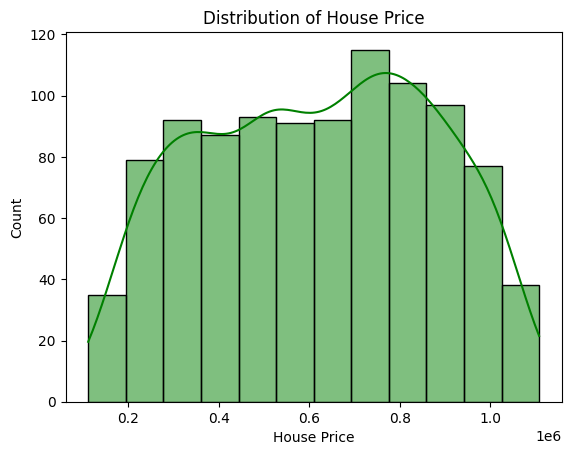

In [12]:
sns.histplot(df['House_Price'],
             kde=True,
             color='green')
plt.title('Distribution of House Price')
plt.xlabel('House Price')
plt.show()

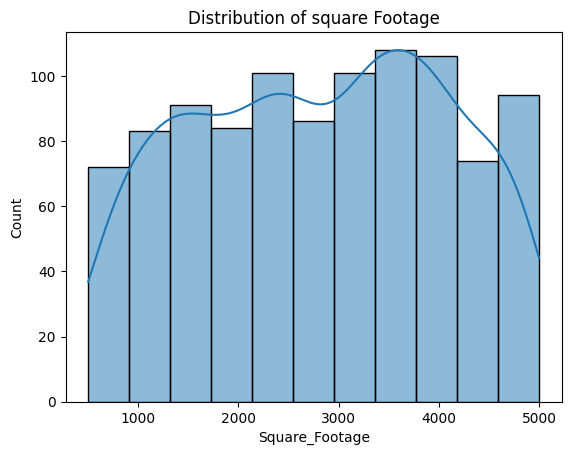

In [13]:
sns.histplot(df['Square_Footage'],
             kde=True)
plt.title('Distribution of square Footage')
plt.show()

In [14]:
df_Num_Bathrooms=df['Num_Bathrooms'].value_counts()
df_Num_Bathrooms=pd.DataFrame(df_Num_Bathrooms)
df_Num_Bathrooms

,count
Num_Bathrooms,
1,350
2,327
3,323


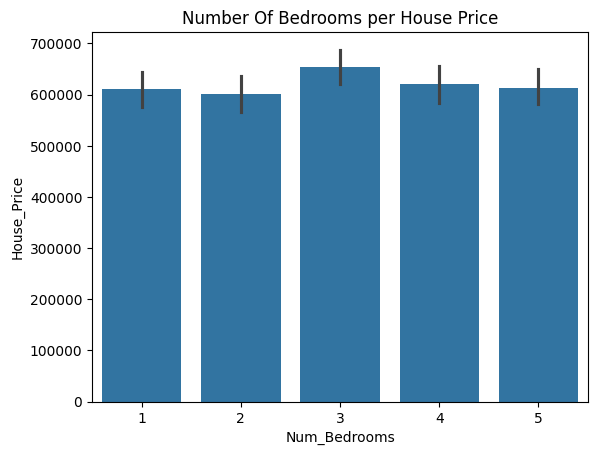

In [15]:
sns.barplot(
    data=df,
    x='Num_Bedrooms',
    y='House_Price',
)
plt.title('Number Of Bedrooms per House Price')
plt.show()

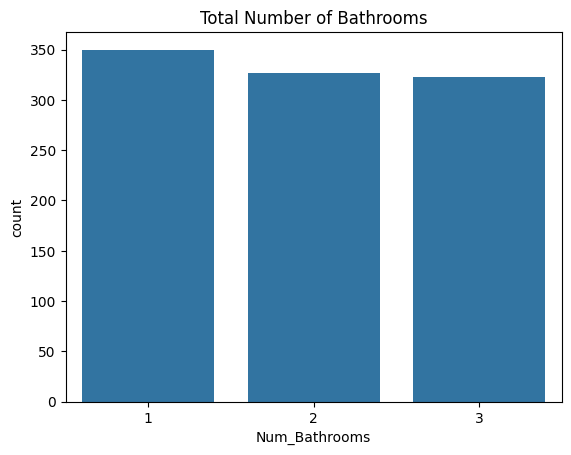

In [16]:
sns.barplot(
    data=df_Num_Bathrooms,
    x=df_Num_Bathrooms.index,
    y='count',
)
plt.title('Total Number of Bathrooms')
plt.show()

In [17]:
df_age=df['House_age'].value_counts()
df_age=pd.DataFrame(df_age)
df_age

,count
House_age,
29,24
48,22
17,21
42,21
8,21
...,...
45,8
24,8
5,8


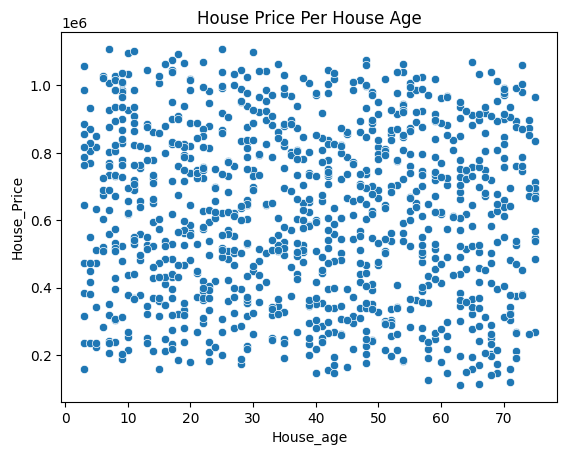

In [18]:
sns.scatterplot(
    data=df,
    x='House_age',
    y='House_Price',
)
plt.title('House Price Per House Age')
plt.show()

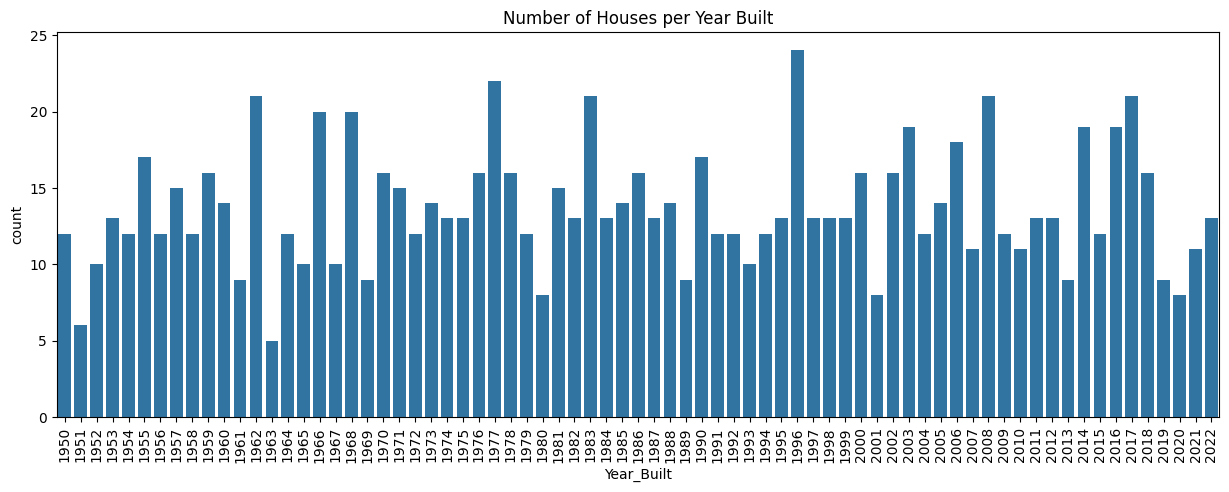

In [19]:
plt.figure(figsize=(15,5))
sns.countplot(
    data=df,
    x='Year_Built',
)
plt.title('Number of Houses per Year Built')
plt.xticks(rotation=90)
plt.show()

<Axes: ylabel='House_Price'>

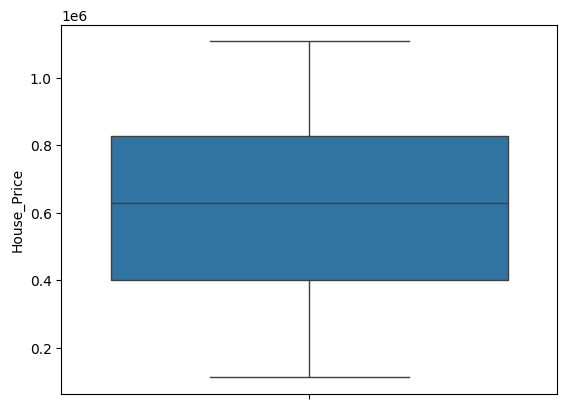

In [20]:
sns.boxplot(df['House_Price'])
#Checking outliers in house price

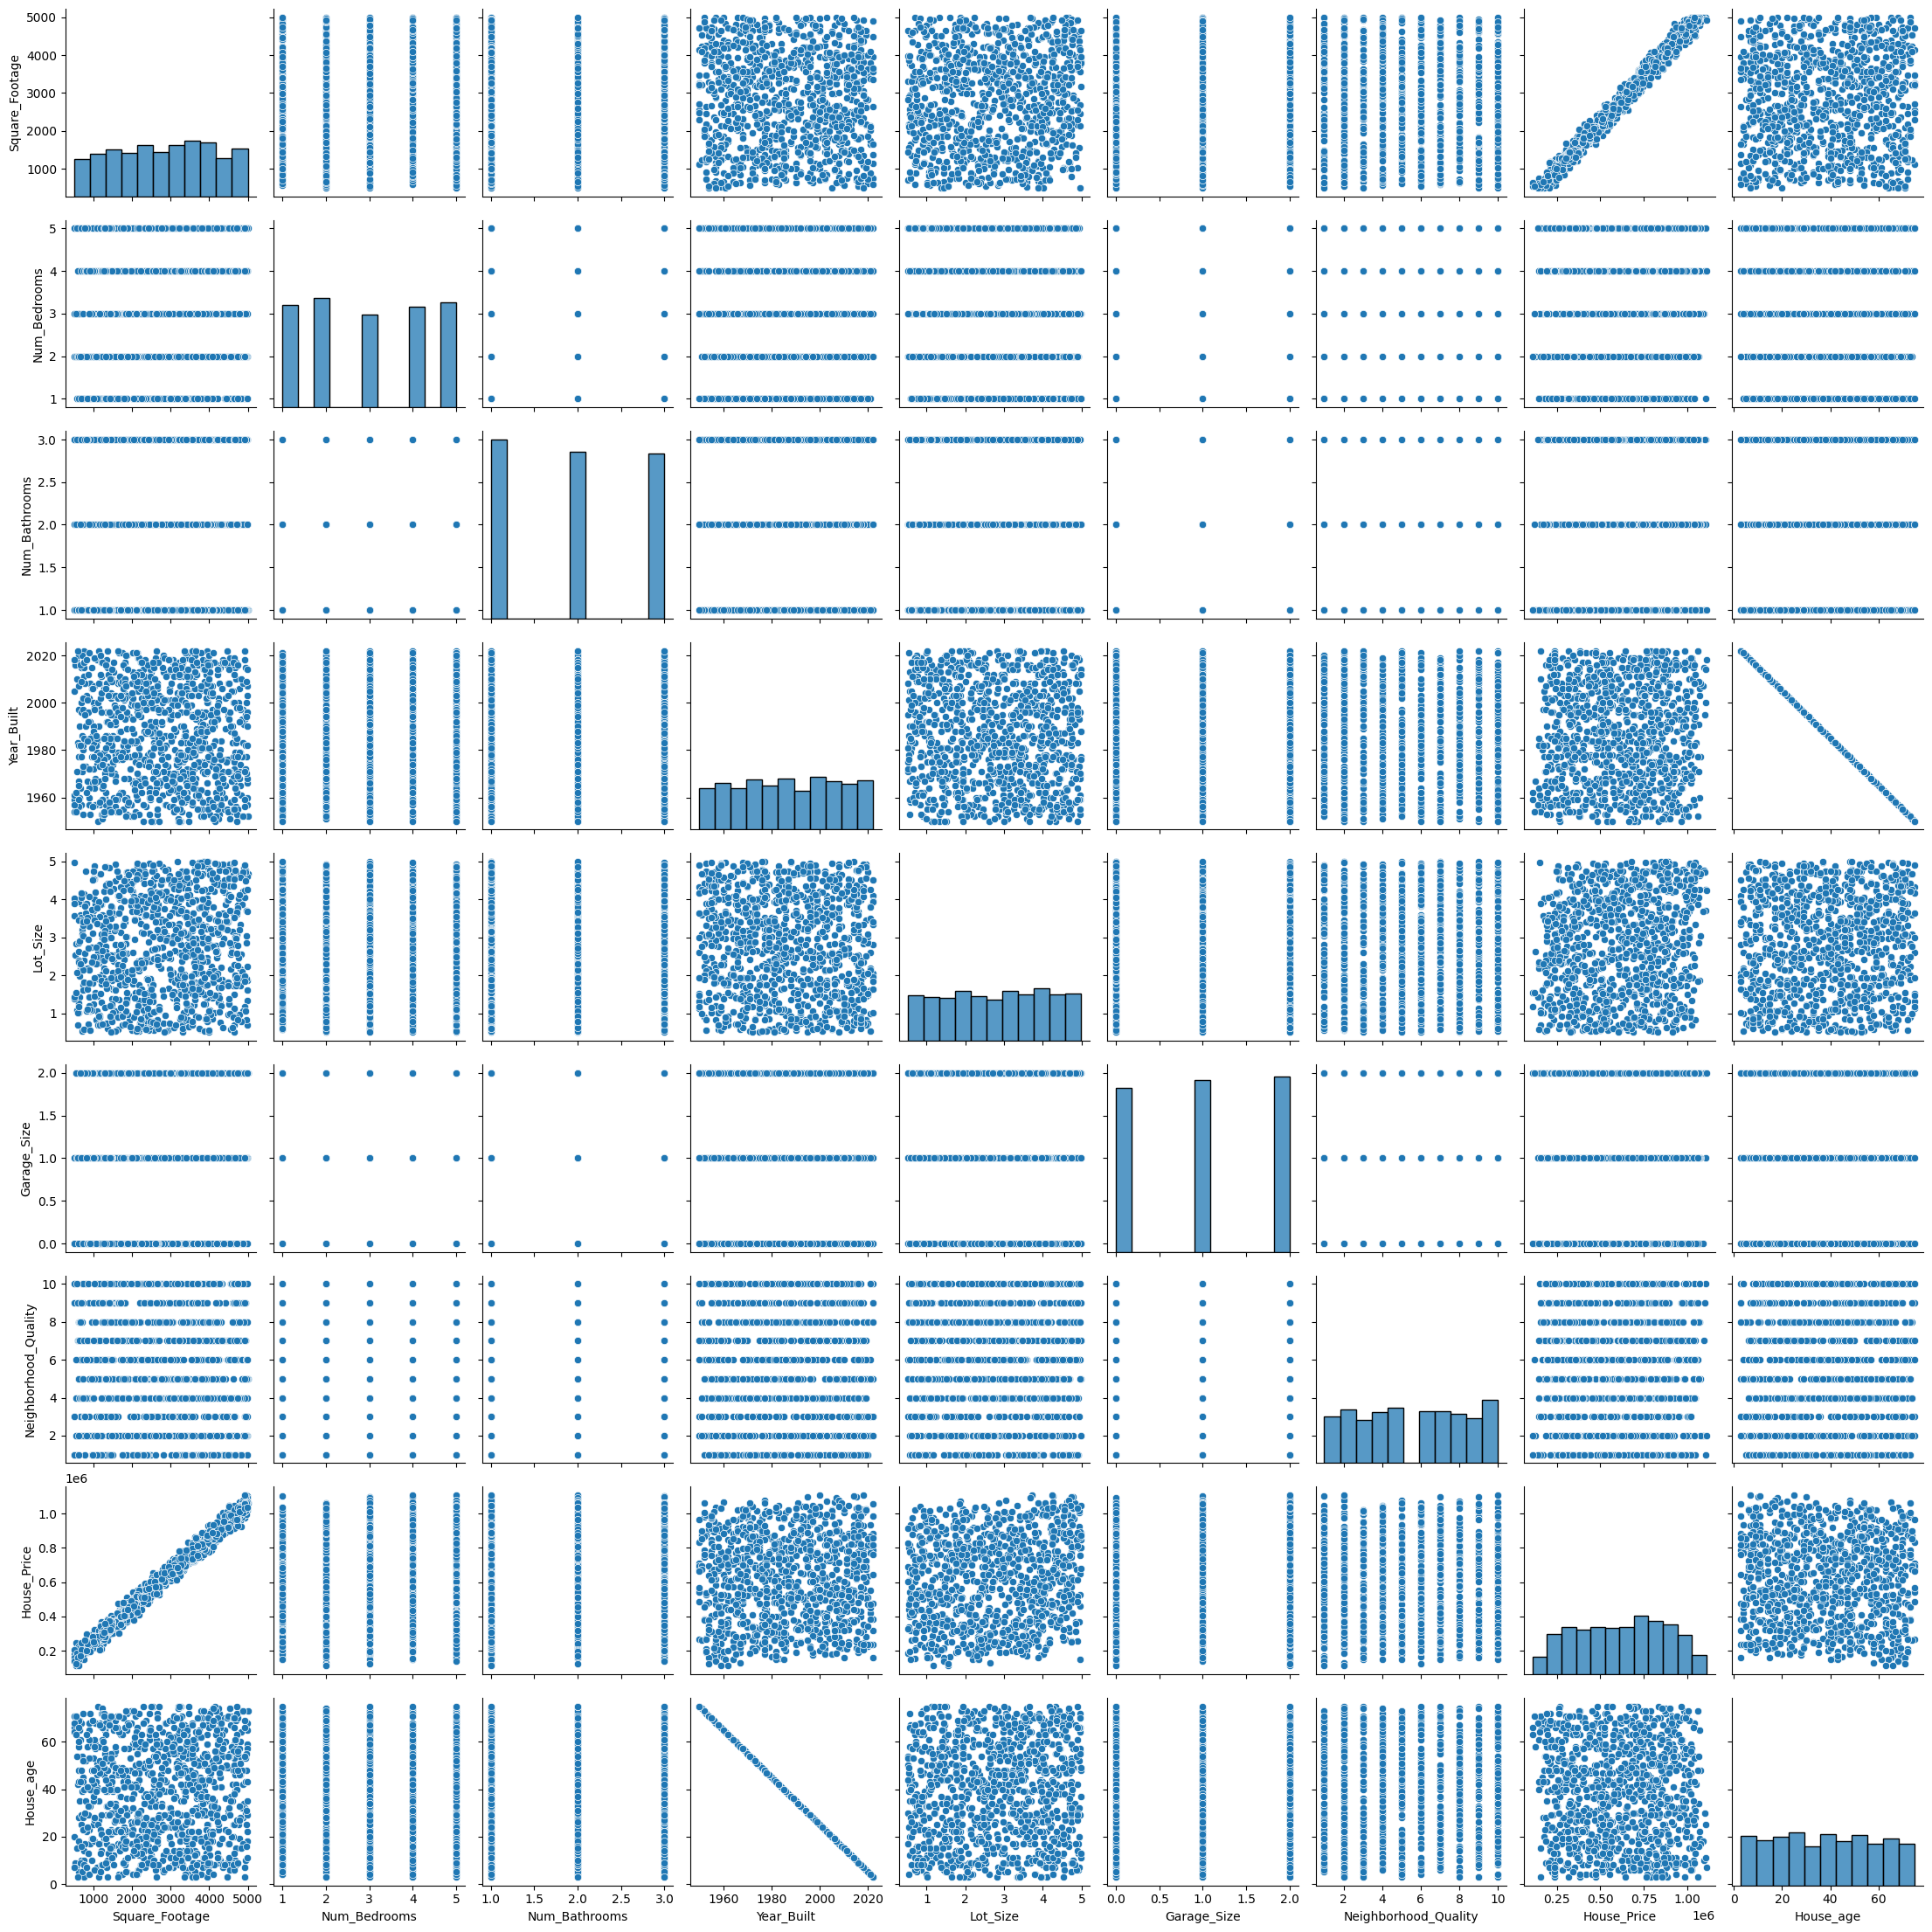

In [21]:
sns.pairplot(df)
plt.show()

In [22]:
df.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price,House_age
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261,0.022392
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633,0.015820
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862,0.021063
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967,-1.000000
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412,0.061050
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133,0.025485
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770,0.009549
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000,-0.051967
House_age,0.022392,0.015820,0.021063,-1.000000,0.061050,0.025485,0.009549,-0.051967,1.000000


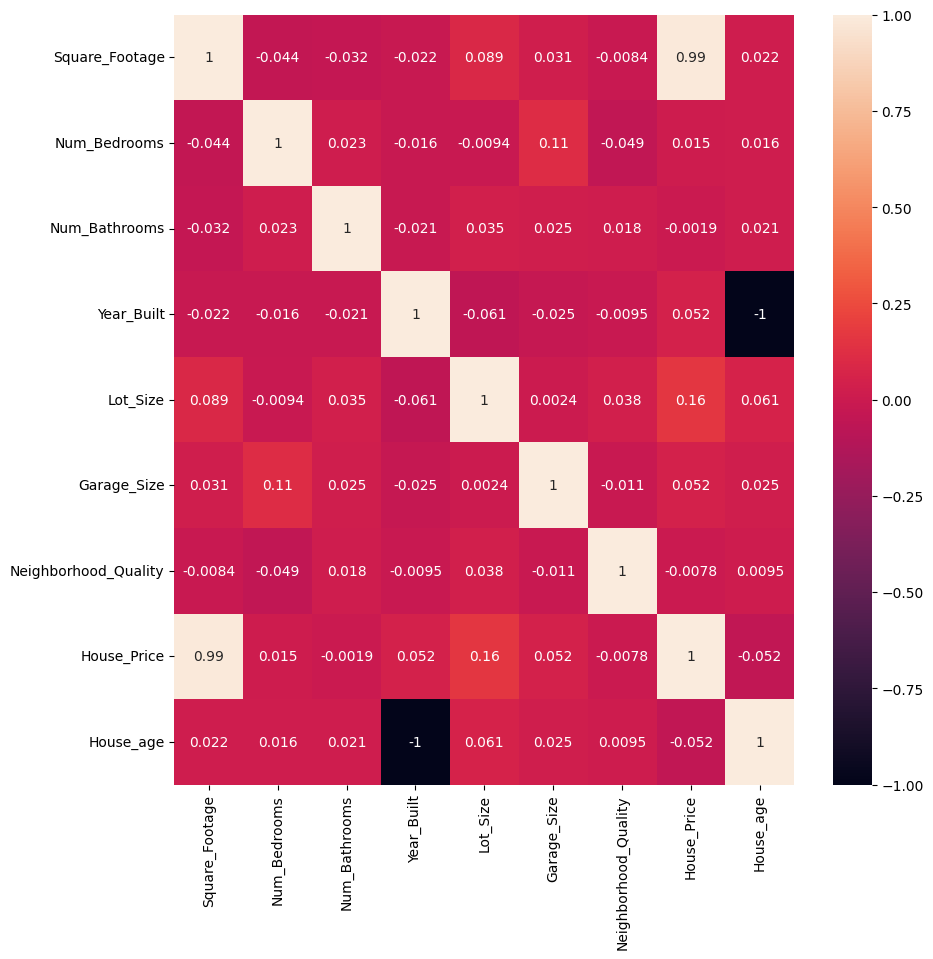

In [23]:
#Plotting Heatmap

plt.figure(figsize=(10,10))
sns.heatmap(
    df.corr(),
    annot=True
)
plt.show()

**Splitting dataset into train and test sets**

In [24]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [25]:
y=df['House_Price']
x=df.drop(['House_Price','Neighborhood_Quality'],axis=1)

In [26]:
x

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,House_age
0,1360,2,1,1981,0.599637,0,44
1,4272,3,3,2016,4.753014,1,9
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,48
4,4926,2,1,1993,4.699073,0,32
...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,47
996,3179,1,2,1999,2.977123,1,26
997,2606,4,2,1962,4.055067,0,63
998,4723,5,2,1950,1.930921,0,75


In [27]:
y

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06
...,...
995,7.014940e+05
996,6.837232e+05
997,5.720240e+05
998,9.648653e+05


In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [29]:
print("Dimensions of x train",x_train.shape)
print("Dimensions of x test",x_test.shape)
print("Dimensions of y train",y_train.shape)
print("Dimensions of y test",y_test.shape)

Dimensions of x train (800, 7)
Dimensions of x test (200, 7)
Dimensions of y train (800,)
Dimensions of y test (200,)




*   The dataset has been partitoned into the training and test sets.
*   This data has 80% training set and 20% testing set.



In [30]:
x_train

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,House_age
29,2028,2,3,1967,1.784790,2,58
535,3519,5,3,1966,4.009947,0,59
695,4507,2,3,2014,4.122337,0,11
557,3371,4,2,2000,1.580318,0,25
836,2871,5,1,1974,3.426914,2,51
...,...,...,...,...,...,...,...
106,2257,5,1,1968,3.131006,0,57
270,3894,3,2,1975,1.256532,0,50
860,1484,5,1,2010,1.246555,1,15
435,1865,4,2,1994,4.354220,0,31


In [31]:
x_test

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,House_age
521,4012,3,1,2016,2.098092,1,9
737,2310,3,1,1988,1.369622,1,37
740,4708,1,3,1962,1.792970,1,63
660,4932,2,1,1972,4.479598,1,53
411,3646,1,1,1994,3.980987,0,31
...,...,...,...,...,...,...,...
408,3767,5,3,1981,1.520335,2,44
332,616,2,3,1965,3.461372,1,60
208,4491,4,2,1994,3.399155,0,31
613,1858,1,1,1996,4.546672,2,29


In [32]:
y_train

,House_Price
29,434165.896634
535,788284.690202
695,985499.196316
557,736289.124555
836,636552.752485
...,...
106,501305.548994
270,797034.425504
860,360372.978039
435,478566.065591


In [33]:
y_test

,House_Price
521,9.010005e+05
737,4.945375e+05
740,9.494042e+05
660,1.040389e+06
411,7.940100e+05
...,...
408,8.245296e+05
332,1.803936e+05
208,9.658167e+05
613,4.336642e+05


In [34]:
X_train1=sm.add_constant(x_train)

In [35]:
X_train1

,const,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,House_age
29,1.0,2028,2,3,1967,1.784790,2,58
535,1.0,3519,5,3,1966,4.009947,0,59
695,1.0,4507,2,3,2014,4.122337,0,11
557,1.0,3371,4,2,2000,1.580318,0,25
836,1.0,2871,5,1,1974,3.426914,2,51
...,...,...,...,...,...,...,...,...
106,1.0,2257,5,1,1968,3.131006,0,57
270,1.0,3894,3,2,1975,1.256532,0,50
860,1.0,1484,5,1,2010,1.246555,1,15
435,1.0,1865,4,2,1994,4.354220,0,31


In [36]:
#Creating the first fitted model
lr1=sm.OLS(y_train,X_train1).fit()

In [37]:
#Checking the parameters obtained
print(lr1.params)

const                -0.489655
Square_Footage      199.509336
Num_Bedrooms      10217.161344
Num_Bathrooms      8225.752595
Year_Built            0.966135
Lot_Size          14895.046804
Garage_Size        5151.385326
House_age          -992.518332
dtype: float64


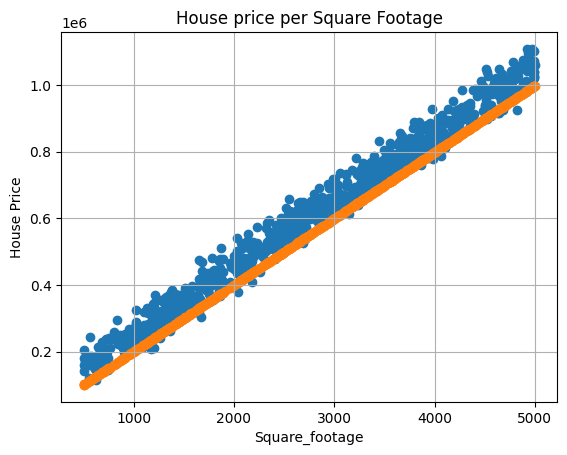

In [38]:

plt.scatter(x_train['Square_Footage'],y_train)
plt.scatter(x_train['Square_Footage'],-0.48+199.5*x_train['Square_Footage'])
plt.title("House price per Square Footage")
plt.xlabel('Square_footage')
plt.ylabel('House Price')
plt.grid()
plt.show()


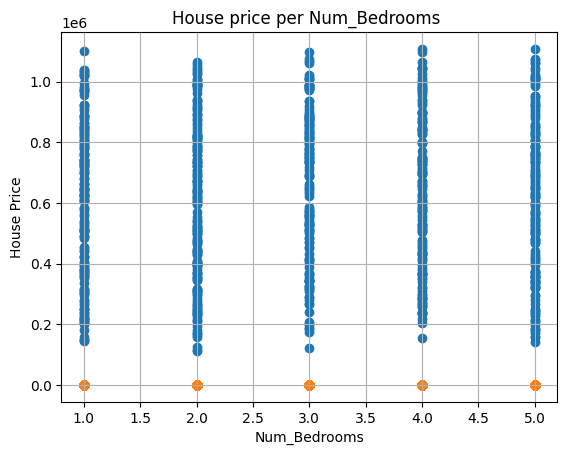

In [39]:
plt.scatter(x_train['Num_Bedrooms'],y_train)
plt.scatter(x_train['Num_Bedrooms'],-0.48+199.5*x_train['Num_Bedrooms'])
plt.title("House price per Num_Bedrooms ")
plt.xlabel('Num_Bedrooms')
plt.ylabel('House Price')
plt.grid()
plt.show()

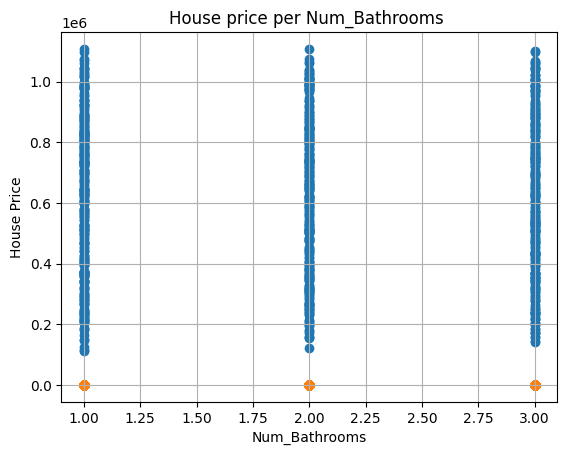

In [40]:
plt.scatter(x_train['Num_Bathrooms'],y_train)
plt.scatter(x_train['Num_Bathrooms'],-0.48+199.5*x_train['Num_Bathrooms'])
plt.title("House price per Num_Bathrooms ")
plt.xlabel('Num_Bathrooms')
plt.ylabel('House Price')
plt.grid()
plt.show()

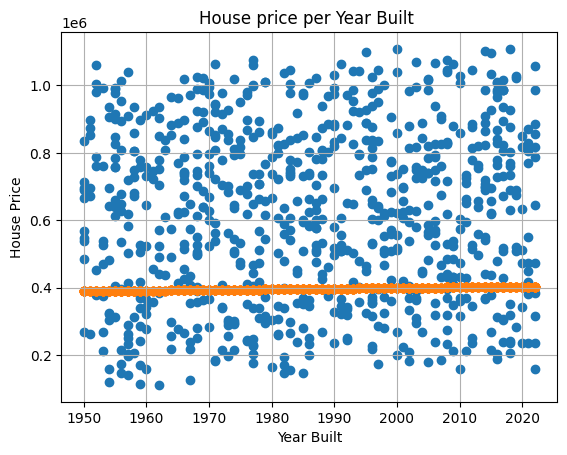

In [41]:
plt.scatter(x_train['Year_Built'],y_train)
plt.scatter(x_train['Year_Built'],-0.48+199.5*x_train['Year_Built'])
plt.title("House price per Year Built ")
plt.xlabel('Year Built')
plt.ylabel('House Price')
plt.grid()
plt.show()

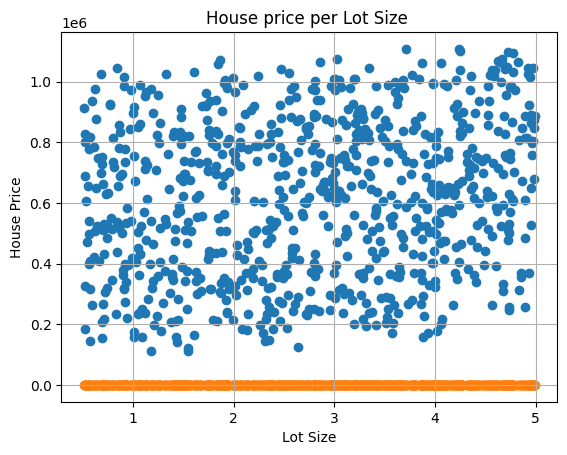

In [42]:
plt.scatter(x_train['Lot_Size'],y_train)
plt.scatter(x_train['Lot_Size'],-0.48+199.5*x_train['Lot_Size'])
plt.title("House price per Lot Size ")
plt.xlabel('Lot Size')
plt.ylabel('House Price')
plt.grid()
plt.show()

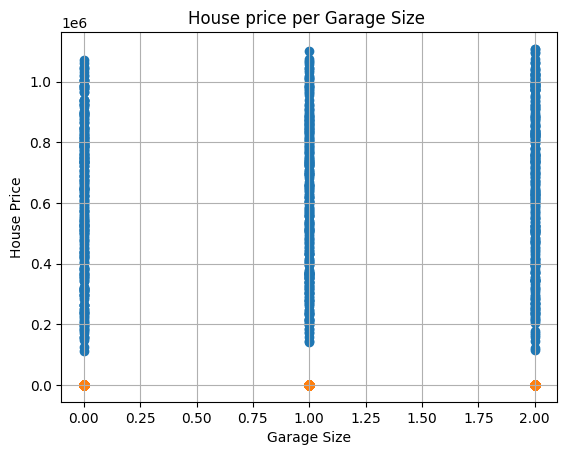

In [43]:
plt.scatter(x_train['Garage_Size'],y_train)
plt.scatter(x_train['Garage_Size'],-0.48+199.5*x_train['Garage_Size'])
plt.title("House price per Garage Size ")
plt.xlabel('Garage Size')
plt.ylabel('House Price')
plt.grid()
plt.show()

In [44]:
#checking the summary of linear regression model obtained
print(lr1.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 9.014e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:18:40   Log-Likelihood:                -8478.5
No. Observations:                 800   AIC:                         1.697e+04
Df Residuals:                     793   BIC:                         1.700e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.4897      0.008    -61.

In [45]:
X_test1=sm.add_constant(x_test)

In [46]:
X_test1

,const,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,House_age
521,1.0,4012,3,1,2016,2.098092,1,9
737,1.0,2310,3,1,1988,1.369622,1,37
740,1.0,4708,1,3,1962,1.792970,1,63
660,1.0,4932,2,1,1972,4.479598,1,53
411,1.0,3646,1,1,1994,3.980987,0,31
...,...,...,...,...,...,...,...,...
408,1.0,3767,5,3,1981,1.520335,2,44
332,1.0,616,2,3,1965,3.461372,1,60
208,1.0,4491,4,2,1994,3.399155,0,31
613,1.0,1858,1,1,1996,4.546672,2,29


In [47]:
lr2=sm.OLS(y_test,X_test1).fit()

In [48]:
print(lr2.params)

const                -0.486165
Square_Footage      200.731568
Num_Bedrooms      10009.542716
Num_Bathrooms      8222.585178
Year_Built           -1.156531
Lot_Size          15168.586755
Garage_Size        5312.779375
House_age          -983.328024
dtype: float64


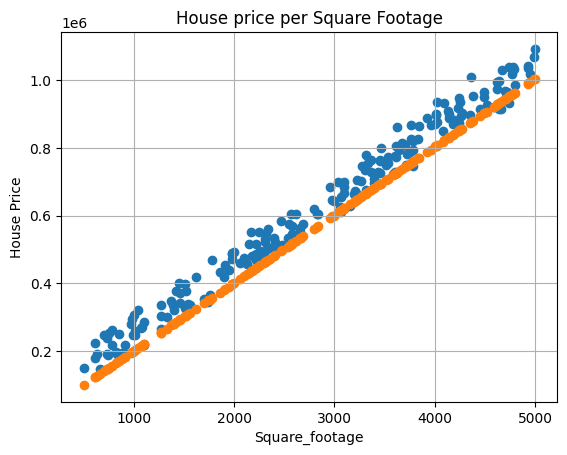

In [49]:
plt.scatter(x_test['Square_Footage'],y_test)
plt.scatter(x_test['Square_Footage'],-0.48+200.7*x_test['Square_Footage'])
plt.title("House price per Square Footage")
plt.xlabel('Square_footage')
plt.ylabel('House Price')
plt.grid()
plt.show()

In [50]:
print(lr2.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.103e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          8.61e-269
Time:                        05:19:36   Log-Likelihood:                -2124.3
No. Observations:                 200   AIC:                             4263.
Df Residuals:                     193   BIC:                             4286.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.4862      0.018    -27.

In [51]:
# Inspect the data
print("--- Head ---")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print("\n--- Info ---")
print(df.info())

--- Head ---
| Square_Footage   | Num_Bedrooms   | Num_Bathrooms   | Year_Built   | Lot_Size   | Garage_Size   | Neighborhood_Quality   | House_Price   | House_age   |
|:-----------------|:---------------|:----------------|:-------------|:-----------|:--------------|:-----------------------|:--------------|:------------|
| 1360             | 2              | 1               | 1981         | 0.599637   | 0             | 5                      | 262383        | 44          |
| 4272             | 3              | 3               | 2016         | 4.75301    | 1             | 6                      | 985261        | 9           |
| 3592             | 1              | 2               | 2016         | 3.63482    | 0             | 9                      | 777977        | 9           |
| 966              | 1              | 2               | 1977         | 2.73067    | 1             | 8                      | 229699        | 48          |
| 4926             | 2              | 1               | 1